# Plots intendend for thesis, but not used

Created 2025-06-08 from the former 2025-05-18 plots.ipynb notebook

### 0 Imports and settings

Load the data from the given paths and create a merged dataAF of the structures present in both the AlphaFold 2 and 3 runs. Also add alternative ranking of the 5 AlphaFold models per prediction:
* RMSD_rank: Ranking the models based on the RMSD_all_atom column (all structures with template available)
* RMSD_peptide_rank: Ranking the models based on the RMSD_all_atom_peptide column (known_DMI, known_DDI and mutations_DMI)
* DockQ_rank: Ranking the models based on the DockQ column (known DMI and DDI)
* Score_rank: Ranking based on the model confidence (AF2) and ranking score (AF3); equal to the ranking in the model_id column (e.g. ranked_0.pdb --> 1, ranked_1.pdb --> 2)

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from typing import Literal

import matplotlib as mpl
from matplotlib.axes._axes import Axes
from matplotlib.figure import Figure
import matplotlib.patches

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import scipy

class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'


In [ ]:
# Settings

# Path to resource folder with the structures and metadata tables
path_resources = Path(r"D:\Eigene Datein\dev\Uni\JGU Bio Bachelorthesis\Daten\resources")

path_AF2 = path_resources / "AF2"
path_AF3 = path_resources / "AF3_hydrogens"
path_solved = path_resources / "solved"

In [ ]:
# Load dataframes
import load_data

dataAF2 = load_data.dataAF2(path=path_AF2 / "AF2_metrics.tsv")
dataAF3 = load_data.dataAF3(path=path_AF3 / f"{path_AF3.name}_metrics.tsv")
dataSolved = load_data.dataSolved(path=path_solved / "solved_hydrogens_metrics.tsv")
dataAF = load_data.dataAF(dataAF2, dataAF3)

In [ ]:
# Display dataframes
print("AlphaFold 2")
display(dataAF2)
print("AlphaFold 3")
display(dataAF3)
print("Benchmark set (AF 2 and 3 inner merge)")
display(dataAF)
print("Experimentally solved structures")
display(dataSolved)

AlphaFold 2


,project_name,run_id,benchmark_set,prediction_name,model_id,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,buried_area,min_distance,disulfide_bonds,salt_bridges,hbonds,hydrophobic_interactions,score_rank,RMSD_rank,RMSD_peptide_rank,DockQ_rank
0,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_0,312,5,A,B,165,...,613.651,6.063,0.0,0,9,0,1,2,2,3
1,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_1,312,5,A,B,165,...,580.310,6.083,0.0,0,9,0,2,3,1,4
2,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_2,312,5,A,B,165,...,662.104,6.072,0.0,0,10,3,3,1,3,5
3,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_3,312,5,A,B,165,...,398.498,5.417,0.0,0,2,0,4,4,4,2
4,AlphaFold_benchmark,run37,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_4,312,5,A,B,165,...,323.304,5.092,0.0,0,2,9,5,5,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3175,AlphaFold_benchmark_DDI,run6,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_0,60,113,B,B,392,...,1617.382,5.591,0.0,3,7,56,1,1,<NA>,<NA>
3176,AlphaFold_benchmark_DDI,run6,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_1,60,113,B,B,392,...,791.256,6.373,0.0,0,3,7,2,5,<NA>,<NA>
3177,AlphaFold_benchmark_DDI,run6,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_2,60,113,B,B,392,...,882.547,7.906,0.0,1,2,11,3,4,<NA>,<NA>
3178,AlphaFold_benchmark_DDI,run6,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_3,60,113,B,B,392,...,1020.896,4.628,0.0,3,7,44,4,3,<NA>,<NA>


AlphaFold 3


,model_preset,benchmark_set,prediction_name,model_id,ranking_score,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,min_distance,disulfide_bonds,salt_bridges,hbonds,hydrophobic_interactions,ipSAE,score_rank,RMSD_rank,RMSD_peptide_rank,DockQ_rank
0,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_0,0.97,312,5,A,B,165,...,6.241,0,0,10,0,0.869025,1,2,1,5
1,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_1,0.97,312,5,A,B,165,...,6.207,0,0,11,0,0.868551,2,3,3,3
2,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_2,0.96,312,5,A,B,165,...,5.810,0,0,13,0,0.855837,3,5,4,1
3,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_3,0.96,312,5,A,B,165,...,6.264,0,0,11,0,0.850758,4,1,2,4
4,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_4,0.96,312,5,A,B,165,...,5.890,0,0,14,0,0.850449,5,4,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3175,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_0,0.36,60,113,B,B,392,...,5.367,0,2,1,0,0.012324,1,1,<NA>,<NA>
3176,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_1,0.23,60,113,B,B,392,...,6.907,0,2,2,15,0.000000,2,5,<NA>,<NA>
3177,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_2,0.22,60,113,B,B,392,...,6.442,0,2,4,0,0.000000,3,4,<NA>,<NA>
3178,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_3,0.21,60,113,B,B,392,...,4.914,0,1,2,48,0.000000,4,3,<NA>,<NA>


Benchmark set (AF 2 and 3 inner merge)


,model_preset,benchmark_set,prediction_name,model_id,ranking_score_AF3,chainA_length,chainB_length,chainA_id,chainB_id,chainA_start,...,Fnonnat_AF2,buried_area_AF2,min_distance_AF2,disulfide_bonds_AF2,salt_bridges_AF2,hbonds_AF2,hydrophobic_interactions_AF2,RMSD_rank_AF2,RMSD_peptide_rank_AF2,DockQ_rank_AF2
0,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_0,0.97,312,5,A,B,165,...,0.086957,613.651,6.063,0.0,0,9,0,2,2,3
1,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_1,0.97,312,5,A,B,165,...,0.050000,580.310,6.083,0.0,0,9,0,3,1,4
2,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_2,0.96,312,5,A,B,165,...,0.185185,662.104,6.072,0.0,0,10,3,1,3,5
3,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_3,0.96,312,5,A,B,165,...,0.363636,398.498,5.417,0.0,0,2,0,4,4,2
4,alphafold3,known_DMI,DEG_APCC_KENBOX_2_4GGD,ranked_4,0.96,312,5,A,B,165,...,0.888889,323.304,5.092,0.0,0,2,9,5,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3165,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_0,0.36,60,113,B,B,392,...,NaN,1617.382,5.591,0.0,3,7,56,1,<NA>,<NA>
3166,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_1,0.23,60,113,B,B,392,...,NaN,791.256,6.373,0.0,0,3,7,5,<NA>,<NA>
3167,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_2,0.22,60,113,B,B,392,...,NaN,882.547,7.906,0.0,1,2,11,4,<NA>,<NA>
3168,alphafold3,random_DDI,D1PF18773_PF00071_2X19.D2PF00009_PF01873_2D74,ranked_3,0.21,60,113,B,B,392,...,NaN,1020.896,4.628,0.0,3,7,44,3,<NA>,<NA>


Experimentally solved structures


,set,PDB_id,DDI_pfam_id,path,chainA_id,chainB_id,min_distance,buried_area,salt_bridges,hbonds,disulfide_bonds,hydrophobic_interactions
0,DMI,1ATP,NaN,DMI_hydrogens\1ATP_min_DMI.pdb,A,B,6.273,808.592,0,1,0,77
1,DMI,1AXC,NaN,DMI_hydrogens\1AXC_min_DMI.pdb,A,B,4.174,1209.332,0,4,0,62
2,DMI,1B72,NaN,DMI_hydrogens\1B72_min_DMI.pdb,A,B,5.182,547.149,0,1,0,36
3,DMI,1B8Q,NaN,DMI_hydrogens\1B8Q_min_DMI.pdb,A,B,4.376,871.756,0,4,0,42
4,DMI,1BXX,NaN,DMI_hydrogens\1BXX_min_DMI.pdb,A,B,4.435,783.465,0,6,0,19
...,...,...,...,...,...,...,...,...,...,...,...,...
183,DDI,3ZNI,PF14447_PF00179,DDI_hydrogens\PF14447_PF00179_3ZNI_AC.pdb,A,C,5.268,1288.881,0,10,0,85
184,DDI,3J7Y,PF14978_PF00327,DDI_hydrogens\PF14978_PF00327_3J7Y_oZ.pdb,o,Z,4.885,2488.556,0,8,0,70
185,DDI,6D6Q,PF15985_PF10175,DDI_hydrogens\PF15985_PF10175_6D6Q_GL.pdb,G,L,3.891,3659.160,1,12,0,167
186,DDI,3KZ1,PF17838_PF00071,DDI_hydrogens\PF17838_PF00071_3KZ1_BE.pdb,B,E,5.276,1249.398,2,10,0,60


In [ ]:
# Stop cell designed to crash to allow "Run All" command in Jupyter notebooks to stop here
raise Exception("STOP")

Exception: STOP

### 1 Plotting the deltas per structure (DDI only)

Not used in the final thesis, but it is interesting to plot only the delta in the RMSD comparison plot

For the domain AF3 is better for 25 structures and AF2 for 21 structures
	When setting 0.5 as threshold, the counts reduces to 12 for AF3 and 34 for AF2
	Both below th: 25
	AF3 max lead: 15.305
	AF2 max lead: -18.418
For the domain AF3 is better for 18 structures and AF2 for 28 structures
	When setting 0.5 as threshold, the counts reduces to 14 for AF3 and 32 for AF2
	Both below th: 10
	AF3 max lead: 60.477
	AF2 max lead: -35.748


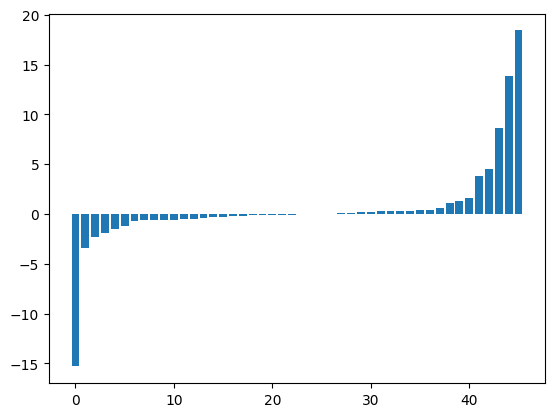

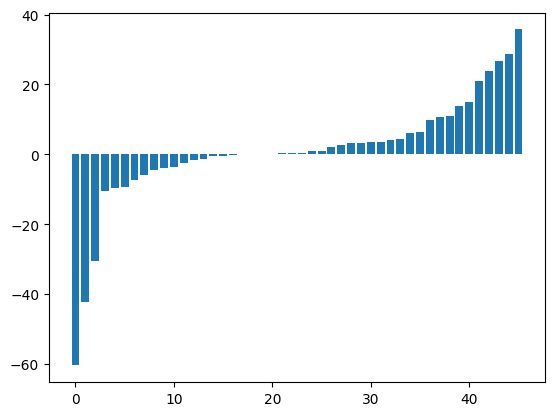

In [ ]:
# Note: Needs the code from Plots part 2, but I didn't bother to copy it here as it is not ready nevertheless

# DDI analyzations
af_domain1_delta = np.array(af2_domain1) - np.array(af3_domain1)
print(f"For the domain AF3 is better for {np.count_nonzero(af_domain1_delta > 0)} structures and AF2 for {np.count_nonzero(af_domain1_delta < 0)} structures")
th = 0.5
print(f"\tWhen setting {th} as threshold, the counts reduces to {np.count_nonzero(af_domain1_delta > th)} for AF3 and {np.count_nonzero(af_domain1_delta < th)} for AF2")
print(f"\tBoth below th: {np.count_nonzero(np.abs(af_domain1_delta) < th)}")
print(f"\tAF3 max lead: {np.max(af_domain1_delta):1.3f}")
print(f"\tAF2 max lead: {np.min(af_domain1_delta):1.3f}")

af_domain2_delta = np.array(af2_domain2) - np.array(af3_domain2)
print(f"For the domain AF3 is better for {np.count_nonzero(af_domain2_delta > 0)} structures and AF2 for {np.count_nonzero(af_domain2_delta < 0)} structures")
th = 0.5
print(f"\tWhen setting {th} as threshold, the counts reduces to {np.count_nonzero(af_domain2_delta > th)} for AF3 and {np.count_nonzero(af_domain2_delta < th)} for AF2")
print(f"\tBoth below th: {np.count_nonzero(np.abs(af_domain2_delta) < th)}")
print(f"\tAF3 max lead: {np.max(af_domain2_delta):1.3f}")
print(f"\tAF2 max lead: {np.min(af_domain2_delta):1.3f}")

plt.bar(range(len(af_domain1_delta)), sorted(-af_domain1_delta))
plt.show()
plt.bar(range(len(af_domain2_delta)), sorted(-af_domain2_delta))
plt.show()

### 2 Anti-correlation of motif RMSD



(8, 8)


AttributeError: 'Axes' object has no attribute 'cmap'

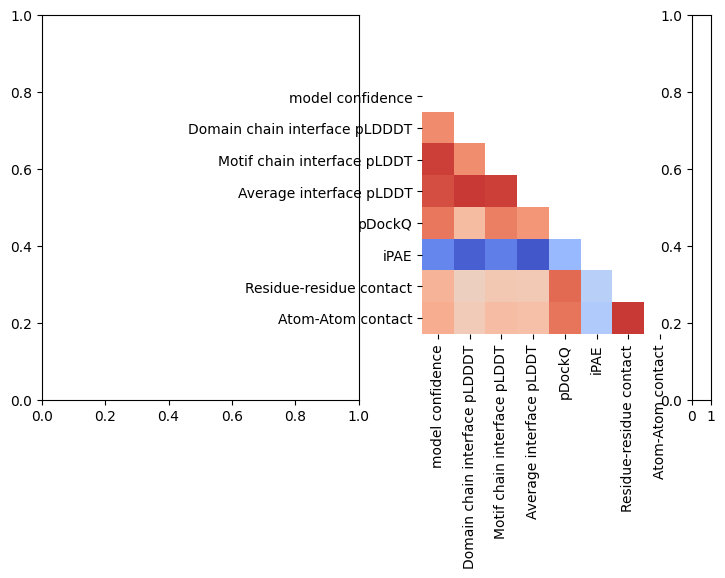

In [ ]:
def plot_motif_RMSD_correlation(ax:Axes, af_v: Literal["AF2", "AF3"], model_filter: bool, save: bool):
    metric_columns = [("model confidence", "model_confidence") if af_v == "AF2" else ("ranking_score", "ranking_score") ,
        ("Domain chain interface pLDDDT", "chainA_intf_avg_plddt"),
        ("Motif chain interface pLDDT", "chainB_intf_avg_plddt"),
        ("Average interface pLDDT", "intf_avg_plddt"),
        ("pDockQ", "pDockQ"),
        ("iPAE", "iPAE"),
        ("Residue-residue contact", "num_res_res_contact"),
        ("Atom-Atom contact", "num_atom_atom_contact"),
    ]
    metric_columns = [[x[0], x[1] + "_"+af_v] for x in metric_columns]

    data_mask = True
    if model_filter:
        data_mask &= (dataAF["model_id"] == "ranked_0")

    data = dataAF[(dataAF["benchmark_set"] == "known_DMI") & data_mask]

    data_vector = [data[c] for label, c in metric_columns]
    cor_matrix = np.corrcoef(data_vector, rowvar=True)
    print(cor_matrix.shape)
    for m in range(len(data_vector)):
        for n in range(m+1):
            cor_matrix[n,m] = None
    ax.imshow(cor_matrix, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(metric_columns)), [label for label, c in metric_columns], rotation=90)
    ax.set_yticks(range(len(metric_columns)), [label for label, c in metric_columns])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    plt.colorbar(ax)
    
    for y, (label_y, column_y) in enumerate(metric_columns):
        for x, (label_x, column_x) in enumerate(metric_columns[:y]):
            pass

fig, axes = plt.subplots(1,2,figsize=(9,5))
plot_motif_RMSD_correlation(axes[1], af_v="AF2", model_filter=True, save=False)
plt.show()

### 2 Correlation between DockQ/ipSAE and RMSD peptide

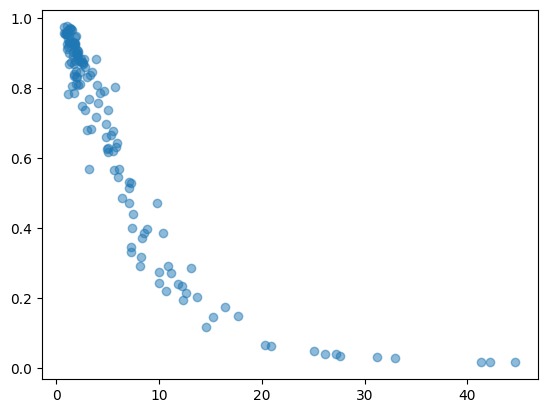

In [ ]:
# How well does RMSD_all_atom peptide and DockQ correlate?
d = dataAF[(dataAF["benchmark_set"] == "known_DMI") & (dataAF["model_id"] == "ranked_0")]
plt.scatter(d["RMSD_all_atom_peptide_AF2"], d["DockQ_AF2"], alpha=0.5)
plt.show()

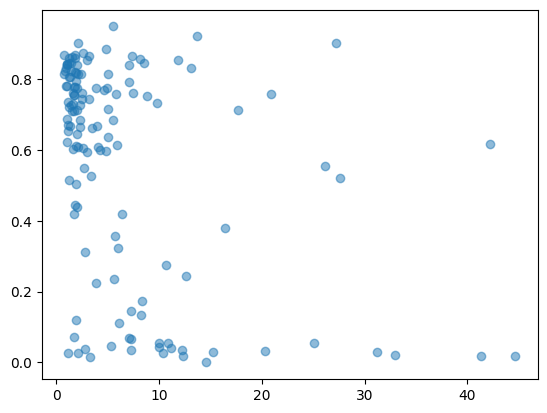

In [ ]:
# How well does ipSAE and RMSD all atom peptide correlate?
d = dataAF[(dataAF["benchmark_set"] == "known_DMI") & (dataAF["model_id"] == "ranked_0")]
plt.scatter(d["RMSD_all_atom_peptide_AF2"], d["ipSAE_AF3"], alpha=0.5)
plt.show()